# DAI101_tut_outliear_regression_PCA

## Outlier detection and effect of outliers in regression


In [112]:
import numpy as np
import pandas as pd
from scipy import stats
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from matplotlib import pyplot as plt
from sklearn.decomposition import PCA

### Use the sklearn library to load the dataset

In [113]:
housing = fetch_california_housing()

df = pd.DataFrame(housing.data, columns=housing.feature_names)
df["Target"] = housing.target

print(df.shape)
df.head()


(20640, 9)


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,Target
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


### Visualize the outliers across any feature using box plot

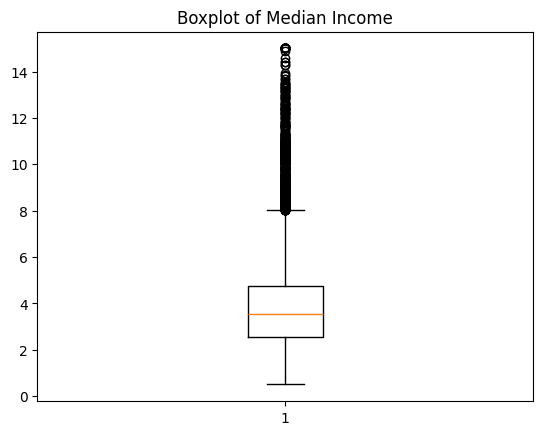

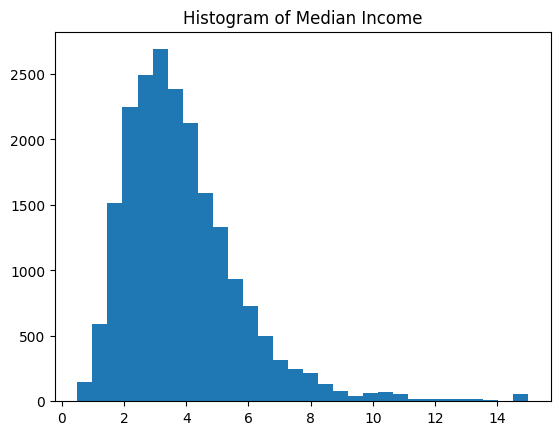

In [ ]:
plt.figure()
plt.boxplot(df["MedInc"])
plt.title("Boxplot of Median Income")
plt.show()

plt.figure()
plt.hist(df["MedInc"], bins=30)
plt.title("Histogram of Median Income")
plt.show()


### Create a function to detect outliers using IQR method. (Good for skewed distribution)

In [ ]:
def detect_outliers_iqr(df, columns):
    bounds = {}
    for col in columns:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR
        bounds[col] = (lower, upper)
    return bounds


### Create a function to detect outliers using Z-score method. (Good for normal distribution)


In [ ]:
def detect_outliers_zscore(df, columns, threshold=3):
    bounds = {}
    for col in columns:
        mean = df[col].mean()
        std = df[col].std()
        lower = mean - threshold * std
        upper = mean + threshold * std
        bounds[col] = (lower, upper)
    return bounds


### Create a function to remove the outliers

In [ ]:
def remove_outliers(df, bounds):
    df_clean = df.copy()
    for col, (lower, upper) in bounds.items():
        df_clean = df_clean[(df_clean[col] >= lower) &
                            (df_clean[col] <= upper)]
    return df_clean


### Create a function for winsorization.
### Winsorization is a simple technique that reduces the impact of extreme outliers by replacing them with specific percentile values

In [ ]:
def cap_outliers(df, bounds):
    df_capped = df.copy()
    for col, (lower, upper) in bounds.items():
        df_capped[col] = np.clip(df_capped[col], lower, upper)
    return df_capped


In [114]:
class OutlierTransformer(BaseEstimator, TransformerMixin):
    def __init__(self, method="iqr", threshold=3):
        self.method = method
        self.threshold = threshold
        self.bounds = {}

    def fit(self, X, y=None):
        columns = X.columns

        if self.method == "iqr":
            self.bounds = detect_outliers_iqr(X, columns)
        elif self.method == "zscore":
            self.bounds = detect_outliers_zscore(X, columns, self.threshold)

        return self

    def transform(self, X):
        return cap_outliers(X, self.bounds)


### Split the dataset for training a linear regression model.

In [115]:
X = df.drop("Target", axis=1)
y = df["Target"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [116]:
print(X_train.shape)
print(X_test.shape)

(16512, 8)
(4128, 8)


### Train a linear regression model

In [117]:
model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("Baseline RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))
print("Baseline R2:", r2_score(y_test, y_pred))


Baseline RMSE: 0.7455813830127764
Baseline R2: 0.5757877060324508


In [118]:
model.coef_

array([ 4.48674910e-01,  9.72425752e-03, -1.23323343e-01,  7.83144907e-01,
       -2.02962058e-06, -3.52631849e-03, -4.19792487e-01, -4.33708065e-01])

In [119]:
model.intercept_

np.float64(-37.02327770606409)

### build a linear regression model after winsorizing the outliers (IQR)

In [120]:
iqr_transformer = OutlierTransformer(method="iqr")
iqr_transformer.fit(X_train)

X_train_iqr = iqr_transformer.transform(X_train)
X_test_iqr = iqr_transformer.transform(X_test)

model_iqr = LinearRegression()
model_iqr.fit(X_train_iqr, y_train)

y_pred_iqr = model_iqr.predict(X_test_iqr)

print("IQR RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_iqr)))
print("IQR R2:", r2_score(y_test, y_pred_iqr))


IQR RMSE: 0.6801313196126653
IQR R2: 0.6469967623855618


In [ ]:
model_iqr.coef_

array([ 5.15286649e-01,  1.35143662e-02, -1.16791457e-01,  1.98679188e+00,
        4.94144430e-05, -3.83355230e-01, -3.83545310e-01, -3.73973815e-01])

In [ ]:
model_iqr.intercept_

np.float64(-31.767262219881154)

### build a linear regression model after winsorizing the outliers (Z-score)


In [121]:
z_transformer = OutlierTransformer(method="zscore", threshold=3)
z_transformer.fit(X_train)

X_train_z = z_transformer.transform(X_train)
X_test_z = z_transformer.transform(X_test)

model_z = LinearRegression()
model_z.fit(X_train_z, y_train)

y_pred_z = model_z.predict(X_test_z)

print("Z-score RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_z)))
print("Z-score R2:", r2_score(y_test, y_pred_z))


Z-score RMSE: 0.7016848017532068
Z-score R2: 0.6242687823519142


# Note: Till now we haven't performed standardization

### Build a pipeline for outliers detection, standardization and linear regression

In [122]:
pipeline_iqr = Pipeline([
    ("outlier", OutlierTransformer(method="iqr")),
    ("scaler", StandardScaler()),
    ("model", LinearRegression())
])

pipeline_iqr.fit(X_train, y_train)

y_pred_iqr = pipeline_iqr.predict(X_test)

print("IQR + Scaling RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_iqr)))
print("IQR + Scaling R2:", r2_score(y_test, y_pred_iqr))


IQR + Scaling RMSE: 0.6801313196126654
IQR + Scaling R2: 0.6469967623855617


In [123]:
pipeline_iqr['model'].coef_

array([ 0.85953834,  0.17030963, -0.14559455,  0.16054844,  0.03779642,
       -0.26475714, -0.81948314, -0.75003919])

In [124]:
pipeline_iqr['model'].intercept_

np.float64(2.0719469373788777)

### Use PCA to visualize the regression line on 2D space

In [125]:
data_preprocessor = pipeline_iqr[:-1]
X_train_preprocessed = data_preprocessor.transform(X_train)
X_test_preprocessed = data_preprocessor.transform(X_test)

In [127]:
pca = PCA(n_components=2)
pca.fit(X_train_preprocessed)

PCA(n_components=2)

In [128]:
X_train_pca = pca.transform(X_train_preprocessed)
X_test_pca = pca.transform(X_test_preprocessed)

In [129]:
print(pca.explained_variance_ratio_)
print(pca.singular_values_)

[0.25942854 0.21882517]
[185.12015591 170.01743941]


In [136]:
np.linspace(0,10,20)

array([ 0.        ,  0.52631579,  1.05263158,  1.57894737,  2.10526316,
        2.63157895,  3.15789474,  3.68421053,  4.21052632,  4.73684211,
        5.26315789,  5.78947368,  6.31578947,  6.84210526,  7.36842105,
        7.89473684,  8.42105263,  8.94736842,  9.47368421, 10.        ])

In [130]:
#Create the grid based on the Training PCA limits
x_min, x_max = X_train_pca[:, 0].min() - 1, X_train_pca[:, 0].max() + 1
y_min, y_max = X_train_pca[:, 1].min() - 1, X_train_pca[:, 1].max() + 1
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 50),
                     np.linspace(y_min, y_max, 50))

In [131]:
#  Map the grid back to the space the Linear Model understands
pca_grid = np.c_[xx.ravel(), yy.ravel()]
X_grid_preprocessed = pca.inverse_transform(pca_grid)

In [132]:
# Note: We use the model step directly because X_grid is already preprocessed
zz = pipeline_iqr.named_steps["model"].predict(X_grid_preprocessed).reshape(xx.shape)

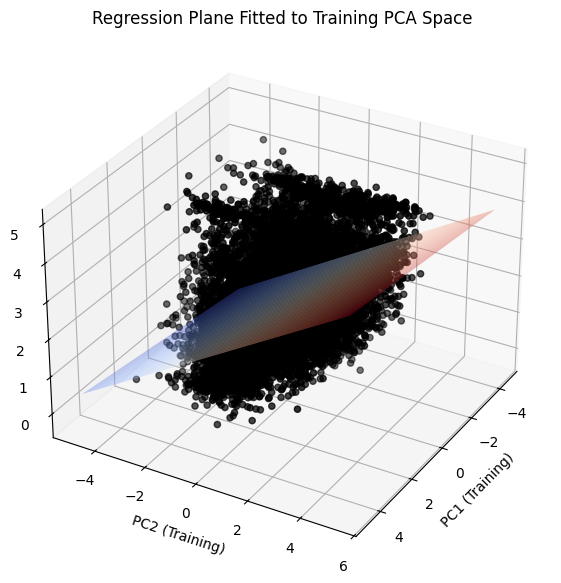

In [133]:
#  Visualization
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')

# Plot the plane derived from the training data
ax.plot_surface(xx, yy, zz, cmap='coolwarm', alpha=0.4)

# Plot the training points
ax.scatter(X_train_pca[:, 0], X_train_pca[:, 1], y_train,
           c='black', s=20, label='Training Data')
ax.view_init(elev=30, azim=30)
ax.set_title("Regression Plane Fitted to Training PCA Space")
ax.set_xlabel("PC1 (Training)")
ax.set_ylabel("PC2 (Training)")
ax.set_zlabel("Target")
plt.show()

In [134]:
import plotly.graph_objects as go
# 2. Create a grid for the regression plane
x_range = np.linspace(X_train_pca[:, 0].min(), X_train_pca[:, 0].max(), 40)
y_range = np.linspace(X_train_pca[:, 1].min(), X_train_pca[:, 1].max(), 40)
xx, yy = np.meshgrid(x_range, y_range)

# Project grid back to high-dim space for the pipeline model
grid_pca = np.c_[xx.ravel(), yy.ravel()]
grid_high_dim = pca.inverse_transform(grid_pca)
zz = pipeline_iqr.named_steps["model"].predict(grid_high_dim).reshape(xx.shape)

# 3. Build the Interactive Plotly Figure
fig = go.Figure()

# --- Trace 1: The Regression Plane (from previous step) ---
fig.add_trace(go.Surface(
    x=x_range, y=y_range, z=zz,
    colorscale='Greys', opacity=0.9, name='Model Plane',
    showscale=False, hoverinfo='skip'
))

# --- Trace 2: Training Data (Blue/Green) ---
fig.add_trace(go.Scatter3d(
    x=X_train_pca[:, 0], y=X_train_pca[:, 1], z=y_train,
    mode='markers',
    marker=dict(size=4, color='blue', opacity=0.5),
    name='Training Data'
))

# # --- Trace 3: Test Data (Red) ---
# fig.add_trace(go.Scatter3d(
#     x=X_test_pca[:, 0], y=X_test_pca[:, 1], z=y_test,
#     mode='markers',
#     marker=dict(size=5, color='red', symbol='diamond', opacity=0.9),
#     name='Test Data'
# ))

# 3. Update Layout for Clarity
fig.update_layout(
    title="Model Generalization: Training vs Test Data in PCA Space",
    scene=dict(
        xaxis_title="PC1",
        yaxis_title="PC2",
        zaxis_title="Target (y)",
        camera=dict(eye=dict(x=1.5, y=1.5, z=0.8)) # Set a good default viewing angle
    ),
    legend=dict(yanchor="top", y=0.9, xanchor="left", x=0.1)
)

fig.show()